# Loading

In [1]:
#conda activate bigfish_env
#jupyter notebook
import os
import bigfish
import bigfish.stack as stack
import bigfish.multistack as multistack
import bigfish.plot as plot
import bigfish.segmentation as segmentation
import bigfish.detection as detection
print("Big-FISH version: {0}".format(bigfish.__version__))

import numpy as np
from skimage import filters, morphology, measure

def crop_to_object(image_array, padding=10, threshold_method='otsu', reference_z=0, reference_c=0):
    """
    Automatically detect and crop to the bounding box of a single object.
    For 5D arrays [t, c, z, x, y], recalculates crop for each timepoint t,
    applies same crop to all channels c within that timepoint.
    For 4D arrays [c, z, x, y], uses single crop for all channels and z-slices.
    
    Parameters:
    -----------
    image_array : numpy.ndarray
        Input image array. Spatial dimensions must be last two axes.
        Examples: (x, y), (z, x, y), (c, z, x, y), (t, c, z, x, y)
    padding : int
        Pixels to add around detected object (default: 10)
    threshold_method : str
        'otsu' or 'triangle' for automatic thresholding
    reference_z : int
        Which z-slice to use for detecting the object (default: 0)
    reference_c : int
        Which channel to use for detecting the object (default: 0)
    
    Returns:
    --------
    cropped : numpy.ndarray
        Cropped image with same number of dimensions as input
    bboxes : tuple or list of tuples
        Single bbox tuple for 2D-4D arrays: (min_row, min_col, max_row, max_col)
        List of bbox tuples for 5D arrays (one per timepoint)
    """
    ndim = image_array.ndim
    
    # Handle 2D arrays
    if ndim == 2:
        reference_image = image_array
        bbox = _detect_object_bbox(reference_image, padding, threshold_method, 
                                   image_array.shape[-2:])
        cropped = image_array[..., bbox[0]:bbox[2], bbox[1]:bbox[3]]
        return cropped, bbox
    
    # Handle 3D arrays [z, x, y]
    elif ndim == 3:
        reference_image = image_array[reference_z]
        bbox = _detect_object_bbox(reference_image, padding, threshold_method, 
                                   image_array.shape[-2:])
        min_row, min_col, max_row, max_col = bbox
        cropped = image_array[:, min_row:max_row, min_col:max_col]
        return cropped, bbox
    
    # Handle 4D arrays [c, z, x, y]
    elif ndim == 4:
        # Detect object using reference channel and z-slice
        reference_image = image_array[reference_c, reference_z]
        bbox = _detect_object_bbox(reference_image, padding, threshold_method, 
                                   image_array.shape[-2:])
        
        # Apply same crop to all channels and z-slices
        min_row, min_col, max_row, max_col = bbox
        cropped = image_array[:, :, min_row:max_row, min_col:max_col]
        return cropped, bbox
    
    # Handle 5D arrays [t, c, z, x, y]
    elif ndim == 5:
        n_timepoints = image_array.shape[0]
        cropped_timepoints = []
        bboxes = []
        
        for t in range(n_timepoints):
            # Detect object using reference channel and z-slice for this timepoint
            reference_image = image_array[t, reference_c, reference_z]
            bbox = _detect_object_bbox(reference_image, padding, threshold_method, 
                                      image_array.shape[-2:])
            
            # Apply same crop to all channels and z-slices at this timepoint
            min_row, min_col, max_row, max_col = bbox
            cropped_t = image_array[t, :, :, min_row:max_row, min_col:max_col]
            cropped_timepoints.append(cropped_t)
            bboxes.append(bbox)
        
        cropped = np.stack(cropped_timepoints, axis=0)
        return cropped, bboxes
    
    else:
        raise ValueError(f"Arrays with {ndim} dimensions not supported")


def _detect_object_bbox(reference_image, padding, threshold_method, spatial_shape):
    """
    Detect bounding box from a single 2D reference image.
    
    Returns:
    --------
    bbox : tuple
        (min_row, min_col, max_row, max_col)
    """
    # Automatic thresholding
    if threshold_method == 'otsu':
        threshold = filters.threshold_otsu(reference_image)
    elif threshold_method == 'triangle':
        threshold = filters.threshold_triangle(reference_image)
    else:
        raise ValueError("threshold_method must be 'otsu' or 'triangle'")
    
    # Create and clean binary mask
    binary_mask = reference_image > threshold
    binary_mask = morphology.binary_opening(binary_mask, morphology.disk(3))
    binary_mask = morphology.binary_closing(binary_mask, morphology.disk(3))
    
    # Find largest object
    labeled_mask = measure.label(binary_mask)
    regions = measure.regionprops(labeled_mask)
    
    if len(regions) == 0:
        raise ValueError("No objects detected in image")
    
    largest_region = max(regions, key=lambda r: r.area)
    min_row, min_col, max_row, max_col = largest_region.bbox
    
    # Apply padding with boundary checks
    min_row = max(0, min_row - padding)
    min_col = max(0, min_col - padding)
    max_row = min(spatial_shape[0], max_row + padding)
    max_col = min(spatial_shape[1], max_col + padding)
    
    return (min_row, min_col, max_row, max_col)


# Example usage

# 4D array [c, z, x, y] = [4, 5, 2304, 2304]
# cropped, bbox = crop_to_object(image_4d, padding=20, reference_z=2, reference_c=0)
# Result:
# - cropped.shape: [4, 5, cropped_x, cropped_y]
# - bbox: single tuple (min_row, min_col, max_row, max_col)
# - All 4 channels and 5 z-slices use the same crop

# 5D array [t, c, z, x, y] = [10, 4, 5, 2304, 2304]
# cropped, bboxes = crop_to_object(image_5d, padding=20, reference_z=2, reference_c=0)
# Result:
# - cropped.shape: [10, 4, 5, cropped_x, cropped_y]
# - bboxes: list of 10 tuples, one per tile


#cropped_rna, bbox = crop_to_object(rna, padding=30, reference_slice=7)
#rna_scaled = stack.rescale(cropped_rna, channel_to_stretch=None)

Big-FISH version: 0.6.2


In [2]:
# input and output directories
path_input = "/Volumes/fsmresfiles/Basic_Sciences/CDB/GoyalLab/People/EmmieGrody/Data/EGS/rawData/EGS023/20251118/max"

# find images
recipe = {
    "fov": ["20251118_bingo_slide4_004", "20251118_EGS023_slide4_012"],
    "opt": "MAX",
    "c": ["Blue", "Red", "Gold", "FarRed", ],
    "ext": "tif",
    "pattern": "fov_opt_c.ext"}

#data_map = [(recipe, path_input)]
#image_generator = multistack.build_stacks(data_map)
#images = list(image_generator)

# Pipeline

In [15]:
# input and output directories
path_input = "/Volumes/fsmresfiles/Basic_Sciences/CDB/GoyalLab/People/EmmieGrody/Data/EGS/rawData/EGS023/20251118/TIFF/"

# find images
recipe = {
    "fov": ["20251118_EGS023_bingo_slide4_004"],
    "opt": "Camera - ",
    "c": ["Blue", "Red", "Gold70", "FarRed", ],
    "ext": "tif",
    "z": ["Z05", "Z06", "Z07", "Z08", "Z09"],
    "pattern": "fov_optc_z.ext"}

data_map = [(recipe, path_input)]
image_generator = multistack.build_stacks(data_map)
images = list(image_generator)
test = images[0]

# cropping to cell
crop_all, bbox = crop_to_object(test, padding=40, reference_z=3, reference_c=2)

# splitting image
# nucleus
nuc = crop_all[0,0,...]
# FISH
rna_all = crop_all[0,1:,...]
crop_pol = rna_all[0]
crop_env = rna_all[1]
crop_nef = rna_all[2]
pol_mip = stack.maximum_projection(crop_pol)
env_mip = stack.maximum_projection(crop_env)
nef_mip = stack.maximum_projection(crop_nef)

# segmentation
# nuc segmentation
nuc_mip = stack.maximum_projection(nuc)
nuc_mask = segmentation.thresholding(nuc_mip, threshold=27000)
nuc_mask = segmentation.clean_segmentation(nuc_mask, small_object_size=2000, fill_holes=True)
nuc_label = segmentation.label_instances(nuc_mask)
# cell segmentation
cell_label = segmentation.cell_watershed(pol_mip, nuc_label, threshold=500, alpha=0.9)
# postprocessing
nuc_label = segmentation.clean_segmentation(nuc_label, delimit_instance=True)
cell_label = segmentation.clean_segmentation(cell_label, smoothness=7, delimit_instance=True)
nuc_label, cell_label = multistack.match_nuc_cell(nuc_label, cell_label, single_nuc=False, cell_alone=True)

# spot detection
spots_pol, threshold_pol = detection.detect_spots(
    images=pol_mip, 
    return_threshold=True, 
    voxel_size=(107, 107),
    spot_radius=(130, 130))
print("pol spots: {0}".format(spots_pol.shape[0]))
spots_env, threshold_env = detection.detect_spots(
    images=env_mip, 
    return_threshold=True, 
    voxel_size=(107, 107),
    spot_radius=(130, 130))
print("env spots: {0}".format(spots_env.shape[0]))
spots_nef, threshold_nef = detection.detect_spots(
    images=nef_mip, 
    return_threshold=True, 
    voxel_size=(107, 107),
    spot_radius=(130, 130))
print("nef spots: {0}".format(spots_nef.shape[0]))

# mask by cell segmentation
spots_pol, spots_out = multistack.identify_objects_in_region(cell_label, spots_pol, ndim=2)
print("spots inside cell:", spots_pol.shape[0])
print("spots outside cell:", spots_out.shape[0])

# cluster detection
pol_post_decomposition, dense_regions, reference_spot = detection.decompose_dense(
    image=pol_mip, 
    spots=spots_pol, 
    voxel_size=(107, 107),
    spot_radius=(130, 130), 
    alpha=0.7,
    beta=1, 
    gamma=5)
#print("spots before decomposition:", spots_pol.shape[0])
#print("spots after decomposition:", spots_post_decomposition.shape[0])
pol_post_clustering, clusters_pol = detection.detect_clusters(
    spots=pol_post_decomposition, 
    voxel_size=(107, 107), 
    radius=600, # max distance between spots in cluster
    nb_min_spots=6)
#print("clusters:", clusters.shape[0])
env_post_decomposition, dense_regions, reference_spot = detection.decompose_dense(
    image=env_mip, 
    spots=spots_env, 
    voxel_size=(107, 107),
    spot_radius=(130, 130), 
    alpha=0.7,
    beta=1, 
    gamma=5)
#print("spots before decomposition:", spots_pol.shape[0])
#print("spots after decomposition:", spots_post_decomposition.shape[0])
env_post_clustering, clusters_env = detection.detect_clusters(
    spots=env_post_decomposition, 
    voxel_size=(107, 107), 
    radius=600, # max distance between spots in cluster
    nb_min_spots=6)
#print("clusters:", clusters.shape[0])
nef_post_decomposition, dense_regions, reference_spot = detection.decompose_dense(
    image=nef_mip, 
    spots=spots_nef, 
    voxel_size=(107, 107),
    spot_radius=(130, 130), 
    alpha=0.7,
    beta=1, 
    gamma=5)
#print("spots before decomposition:", spots_pol.shape[0])
#print("spots after decomposition:", spots_post_decomposition.shape[0])
nef_post_clustering, clusters_nef = detection.detect_clusters(
    spots=nef_post_decomposition, 
    voxel_size=(107, 107), 
    radius=600, # max distance between spots in cluster
    nb_min_spots=6)
#print("clusters:", clusters.shape[0])

# remove transcription site
pol_no_ts, foci_pol, ts = multistack.remove_transcription_site(pol_post_clustering, clusters_pol, nuc_label, ndim=2)
#print("spots w/o hubs:", spots_no_ts.shape[0])
env_no_ts, foci_env, ts = multistack.remove_transcription_site(env_post_clustering, clusters_env, nuc_label, ndim=2)
#print("spots w/o hubs:", spots_no_ts.shape[0])
nef_no_ts, foci_nef, ts = multistack.remove_transcription_site(nef_post_clustering, clusters_nef, nuc_label, ndim=2)
#print("spots w/o hubs:", spots_no_ts.shape[0])

# Colocalization
# keeps only colocalized spots
print("nef spots:", nef_no_ts[:,:2].shape[0])
# Unspliced
(USSS_nef, USSS_env, 
 distances) = multistack.detect_spots_colocalization(
    spots_1=nef_no_ts[:,:2], 
    spots_2=env_no_ts[:,:2],
    voxel_size=(107, 107),
    return_indices=False)
#print("US/SS spots:", USSS_nef.shape[0])
(US_nef, US_pol, 
 distances) = multistack.detect_spots_colocalization(
    spots_1=USSS_nef, 
    spots_2=pol_no_ts[:,:2],
    voxel_size=(107, 107),
    return_indices=False)
print("US spots:", US_nef.shape[0])

# Helper function to convert spots to structured array for exact matching
def spots_to_structured(spots):
    """Convert spots array to structured array for row-wise comparison"""
    if spots.shape[1] == 2:  # 2D coordinates (y, x)
        dtype = [('y', spots.dtype), ('x', spots.dtype)]
    elif spots.shape[1] == 3:  # 3D coordinates (y, x, z)
        dtype = [('y', spots.dtype), ('x', spots.dtype), ('z', spots.dtype)]
    else:
        raise ValueError(f"Unexpected number of columns: {spots.shape[1]}")
    return np.core.records.fromarrays(spots.T, dtype=dtype)

# Singly spliced
USSS_struct = spots_to_structured(USSS_nef)
US_struct = spots_to_structured(US_nef)
mask_SS = ~np.isin(USSS_struct, US_struct)
SS_spots = USSS_nef[mask_SS]

print("SS spots:", SS_spots.shape[0])

# Multiply spliced
spots_nef_struct = spots_to_structured(nef_no_ts[:,:2])
USSS_struct = spots_to_structured(USSS_nef)
mask_MS = ~np.isin(spots_nef_struct, USSS_struct)
MS_spots = nef_no_ts[:,:2][mask_MS]

print("MS spots:", MS_spots.shape[0])


pol spots: 79
env spots: 103
nef spots: 104
spots inside cell: 78
spots outside cell: 1
nef spots: 95
US spots: 25
SS spots: 36
MS spots: 34


In [13]:
t=pol_no_ts[:,1:3]
print(pol_no_ts.shape)
print(t.shape)
print(spots_pol.shape)

(76, 3)
(76, 2)
(78, 2)


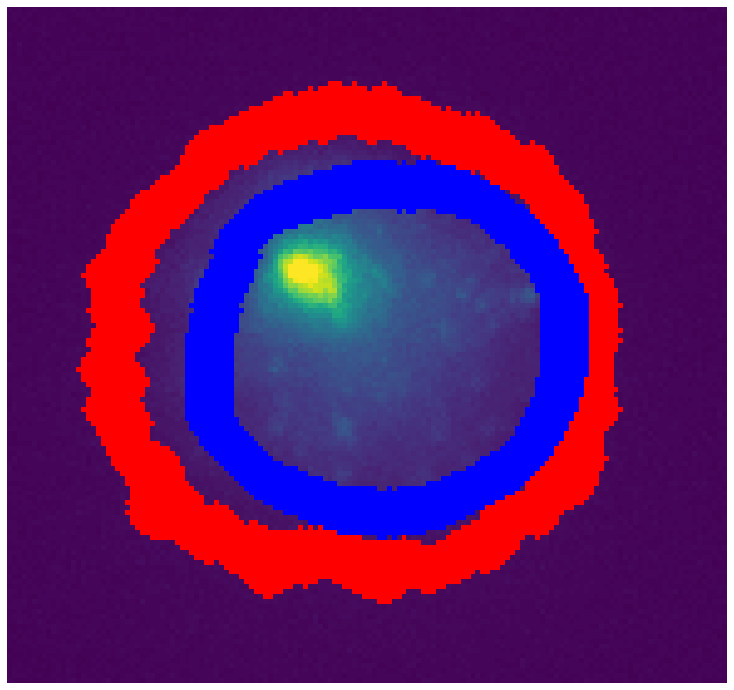

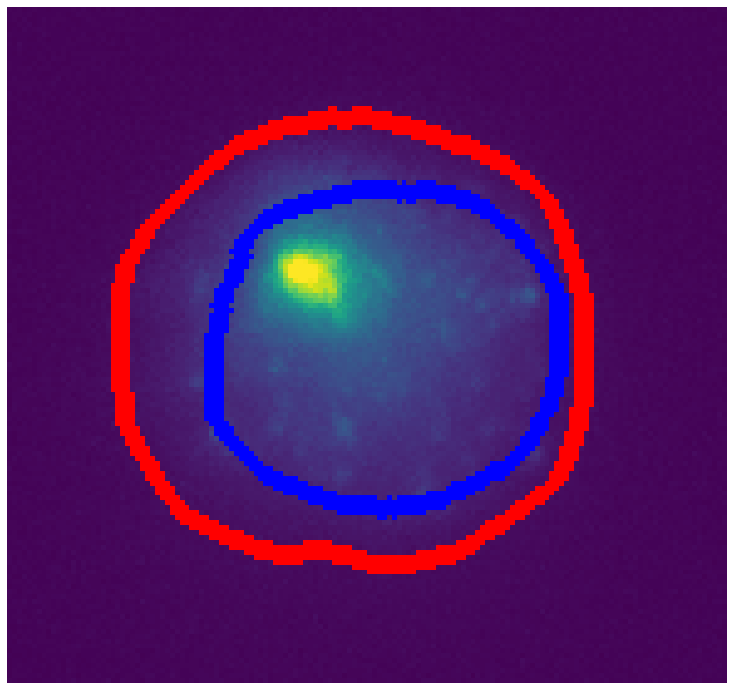

In [26]:
# Saving
# spots
path_output = "/Volumes/fsmresfiles/Basic_Sciences/CDB/GoyalLab/People/EmmieGrody/Data/EGS/extractedData/EGS023/big-FISH/20251118_EGS023_bingo_slide4_004"
stack.save_data_to_csv(SS_spots, os.path.join(path_output, 'SS_spots.csv'), delimiter=",")
stack.save_data_to_csv(MS_spots, os.path.join(path_output, 'MS_spots.csv'), delimiter=",")
stack.save_data_to_csv(US_spots, os.path.join(path_output, 'US_spots.csv'), delimiter=",")
# foci
stack.save_data_to_csv(foci, os.path.join(path_output, 'foci.csv'), delimiter=",")

# nucleus and cell labels
path = os.path.join(path_output, "nuc_label.tif")
stack.save_image(nuc_label, path)
path = os.path.join(path_output, "cell_label.tif")
stack.save_image(cell_label, path)

# Loading

In [ ]:
#load all layers:
# segmented cells
path = os.path.join(path_output, "cell_label.tif")
cell_label = stack.read_image(path)
print("segmented cells")
print("\r shape: {0}".format(cell_label.shape))
print("\r dtype: {0}".format(cell_label.dtype), "\n")

# segmented nuclei
path = os.path.join(path_output, "nuc_label.tif")
nuc_label = stack.read_image(path)
print("segmented nuclei")
print("\r shape: {0}".format(nuc_label.shape))
print("\r dtype: {0}".format(nuc_label.dtype), "\n")

# detected spots
path = os.path.join(path_output, "spots.csv")
spots = stack.read_array_from_csv(path, dtype=np.int64)
print("detected spots")
print("\r shape: {0}".format(spots.shape))
print("\r dtype: {0}".format(spots.dtype), "\n")

# detected foci
path = os.path.join(path_output, "clusters.csv")
clusters = stack.read_array_from_csv(path, dtype=np.int64)
print("detected clusters")
print("\r shape: {0}".format(clusters.shape))
print("\r dtype: {0}".format(clusters.dtype))

spots (subpixel fitting)
 shape: (78, 2)
 dtype: float64


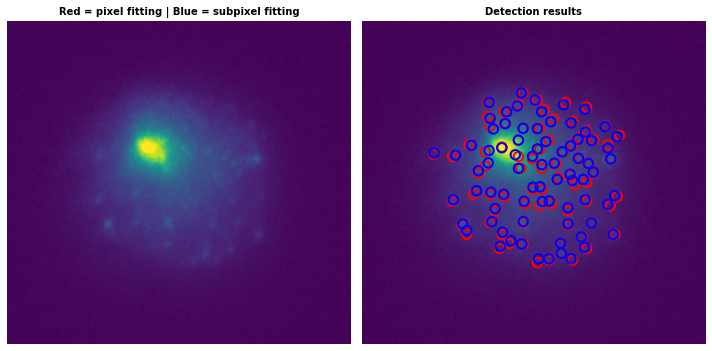

In [129]:
# NOT UPDATED
# subpixel fitting
spots_subpixel_crop = detection.fit_subpixel(
    image=pol_mip, 
    spots=spots_pol, 
    voxel_size=(103, 103), 
    spot_radius=(130, 130))
print("spots (subpixel fitting)")
print("\r shape: {0}".format(spots_subpixel_crop.shape))

plot.plot_detection(
    pol_mip, 
    spots=[spots_pol, spots_subpixel_crop], 
    radius=2, 
    color=["red", "blue"],
    title="Red = pixel fitting | Blue = subpixel fitting",
    linewidth=2, contrast=True, framesize=(10, 5))